✅ Saved ccna_pred_probs_fixed.csv with 'image_pred' column.


===== Loading bio =====
🔢 Converted string labels for bio: {'MCI': 0, 'Normal': 1}
bio: 56 rows, 1 prob columns (safe loaded)

===== Loading sleep =====
sleep: 238 rows, 3 prob columns (safe loaded)

===== Loading lang =====
⚠️ Length mismatch for lang: y_pred=821, p_pred=1173 — truncating.
lang: 821 rows, 4 prob columns (safe loaded)
✅ Created simulated fusion dataset with 154 rows.
💾 Saved fusion dataset: ccna_simulated_fusion_dataset.csv

=== CCNA FUSION META-MODEL RESULTS ===
Accuracy: 0.516

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.69      0.59        16
           1       0.50      0.33      0.40        15

    accuracy                           0.52        31
   macro avg       0.51      0.51      0.50        31
weighted avg       0.51      0.52      0.50        31

Confusion Matrix:
 [[11  5]
 [10  5]]
✅ Saved: ccna_simulated_fusion_meta_model_resul

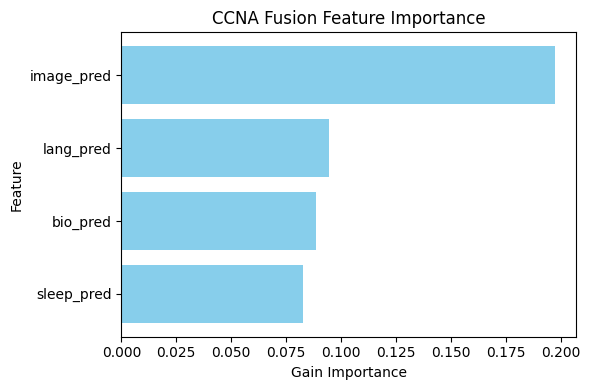

In [ ]:
# ======================================================
# 🧠 CCNA SIMULATED FUSION PIPELINE (FINAL SAFE VERSION)
# ======================================================

import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ------------------------------------------------------
# STEP 1: Fix MRI CSV and rename column
# ------------------------------------------------------
df = pd.read_csv("ccna_pred_probs.csv")
if "ccna_pred" in df.columns:
    df.rename(columns={"ccna_pred": "image_pred"}, inplace=True)
df.to_csv("ccna_pred_probs_fixed.csv", index=False)
print("✅ Saved ccna_pred_probs_fixed.csv with 'image_pred' column.\n")

# ------------------------------------------------------
# STEP 2: Robust .pkl loader (handles mismatched shapes + string labels)
# ------------------------------------------------------
def load_pkl_preds(path, name):
    with open(path, "rb") as f:
        data = pickle.load(f)

    print(f"\n===== Loading {name} =====")
    y_pred = np.array(data["y_pred"])
    p_pred = np.array(data["p_pred"])

    # 🔹 Convert string labels → integers
    if y_pred.dtype.kind in {"U", "S", "O"}:
        unique_labels = sorted(set(y_pred))
        mapping = {label: i for i, label in enumerate(unique_labels)}
        y_pred = np.array([mapping[val] for val in y_pred])
        print(f"🔢 Converted string labels for {name}: {mapping}")

    # ✅ Force consistent 2D shape
    if p_pred.ndim == 1:
        p_pred = p_pred.reshape(-1, 1)
    elif p_pred.ndim > 2:
        p_pred = p_pred.squeeze()

    # ✅ Handle mismatched lengths safely
    n = len(y_pred)
    n_probs = p_pred.shape[1] if p_pred.ndim == 2 else 1
    if p_pred.shape[0] != n:
        print(f"⚠️ Length mismatch for {name}: y_pred={n}, p_pred={p_pred.shape[0]} — truncating.")
        min_len = min(n, p_pred.shape[0])
        y_pred = y_pred[:min_len]
        p_pred = p_pred[:min_len, ...]

    # ✅ Build DataFrame
    df = pd.DataFrame({f"{name}_pred": y_pred})
    for i in range(n_probs):
        df[f"{name}_prob_class_{i}"] = p_pred[:, i] if n_probs > 1 else p_pred.flatten()

    print(f"{name}: {len(df)} rows, {n_probs} prob columns (safe loaded)")
    return df.reset_index(drop=True)

# ------------------------------------------------------
# STEP 3: Simulated fusion generator (random sampling)
# ------------------------------------------------------
def simulate_fusion(mri_df, bio_df, sleep_df, lang_df):
    rng = np.random.default_rng(42)
    n = len(mri_df)
    rows = []

    for i in range(n):
        r = {
            "ID": mri_df.loc[i, "ID"],
            "true_label": int(mri_df.loc[i, "true_label"]),
            "image_pred": int(mri_df.loc[i, "image_pred"]),
        }

        def random_sample(df, prefix):
            if df is None or df.empty:
                r[f"{prefix}_pred"] = np.nan
                return
            idx = rng.integers(0, len(df))
            row = df.iloc[int(idx)]
            val = row[f"{prefix}_pred"]
            # ensure numeric
            if isinstance(val, str):
                val = {"CN": 0, "MCI": 1, "AD": 2}.get(val, np.nan)
            r[f"{prefix}_pred"] = int(val)

        random_sample(bio_df, "bio")
        random_sample(sleep_df, "sleep")
        random_sample(lang_df, "lang")
        rows.append(r)

    fusion_df = pd.DataFrame(rows).dropna()
    print(f"✅ Created simulated fusion dataset with {fusion_df.shape[0]} rows.")
    fusion_df.to_csv("ccna_simulated_fusion_dataset.csv", index=False)
    print("💾 Saved fusion dataset: ccna_simulated_fusion_dataset.csv")
    return fusion_df

# ------------------------------------------------------
# STEP 4: Train fusion meta-model (XGBoost)
# ------------------------------------------------------
def train_meta_model(fusion_df, dataset_name):
    X = fusion_df[["bio_pred", "sleep_pred", "lang_pred", "image_pred"]].astype(int)
    y = fusion_df["true_label"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist"
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    print(f"\n=== {dataset_name} FUSION META-MODEL RESULTS ===")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # ✅ Save predictions
    out = X_test.copy()
    out["true_label"] = y_test.values
    out["meta_model_prediction"] = y_pred
    for i in range(y_prob.shape[1]):
        out[f"prob_class_{i}"] = y_prob[:, i]

    out.to_csv(f"{dataset_name.lower()}_simulated_fusion_meta_model_results.csv", index=False)
    print(f"✅ Saved: {dataset_name.lower()}_simulated_fusion_meta_model_results.csv\n")

    # ✅ Feature importance visualization
    importance = model.get_booster().get_score(importance_type="gain")
    imp_df = pd.DataFrame({
        "Feature": list(importance.keys()),
        "Gain Importance": list(importance.values())
    }).sort_values(by="Gain Importance", ascending=False)

    imp_df.to_csv("ccna_fusion_feature_importance.csv", index=False)
    print("💾 Saved feature importances: ccna_fusion_feature_importance.csv")

    plt.figure(figsize=(6, 4))
    plt.barh(imp_df["Feature"], imp_df["Gain Importance"], color="skyblue")
    plt.xlabel("Gain Importance")
    plt.ylabel("Feature")
    plt.title(f"{dataset_name} Fusion Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("ccna_fusion_feature_importance.png", dpi=300)
    print("📊 Saved feature importance plot: ccna_fusion_feature_importance.png")

# ------------------------------------------------------
# STEP 5: Run CCNA fusion
# ------------------------------------------------------
if __name__ == "__main__":
    mri = pd.read_csv("ccna_pred_probs_fixed.csv")
    bio = load_pkl_preds("ccna_results.pkl", "bio")
    sleep = load_pkl_preds("ccna_sleep_results.pkl", "sleep")
    lang = load_pkl_preds("ccna_language_results.pkl", "lang")

    fusion_df = simulate_fusion(mri, bio, sleep, lang)
    train_meta_model(fusion_df, "CCNA")


✅ Saved ccna_pred_probs_fixed.csv with 'image_pred' column.


===== Loading bio =====
🔢 Converted string labels for bio: {'MCI': 0, 'Normal': 1}
bio: 56 rows, 1 prob columns (safe loaded)

===== Loading sleep =====
sleep: 238 rows, 3 prob columns (safe loaded)

===== Loading lang =====
⚠️ Length mismatch for lang: y_pred=821, p_pred=1173 — truncating.
lang: 821 rows, 4 prob columns (safe loaded)
✅ Created simulated fusion dataset with 154 rows.
💾 Saved fusion dataset: ccna_simulated_fusion_dataset.csv

=== CCNA FUSION META-MODEL RESULTS ===
Accuracy: 0.516

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.69      0.59        16
           1       0.50      0.33      0.40        15

    accuracy                           0.52        31
   macro avg       0.51      0.51      0.50        31
weighted avg       0.51      0.52      0.50        31

Confusion Matrix:
 [[11  5]
 [10  5]]
💾 Saved full result summary: ccna_fusion_result

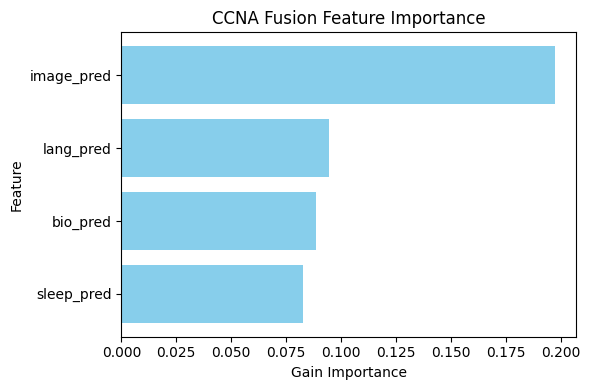

In [ ]:
# ======================================================
# 🧠 CCNA SIMULATED FUSION PIPELINE (RESULTS SAVING ENABLED)
# ======================================================

import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import json

# ------------------------------------------------------
# STEP 1: Fix MRI CSV and rename column
# ------------------------------------------------------
df = pd.read_csv("ccna_pred_probs.csv")
if "ccna_pred" in df.columns:
    df.rename(columns={"ccna_pred": "image_pred"}, inplace=True)
df.to_csv("ccna_pred_probs_fixed.csv", index=False)
print("✅ Saved ccna_pred_probs_fixed.csv with 'image_pred' column.\n")

# ------------------------------------------------------
# STEP 2: Robust .pkl loader
# ------------------------------------------------------
def load_pkl_preds(path, name):
    with open(path, "rb") as f:
        data = pickle.load(f)

    print(f"\n===== Loading {name} =====")
    y_pred = np.array(data["y_pred"])
    p_pred = np.array(data["p_pred"])

    if y_pred.dtype.kind in {"U", "S", "O"}:
        unique_labels = sorted(set(y_pred))
        mapping = {label: i for i, label in enumerate(unique_labels)}
        y_pred = np.array([mapping[val] for val in y_pred])
        print(f"🔢 Converted string labels for {name}: {mapping}")

    if p_pred.ndim == 1:
        p_pred = p_pred.reshape(-1, 1)
    elif p_pred.ndim > 2:
        p_pred = p_pred.squeeze()

    n = len(y_pred)
    n_probs = p_pred.shape[1] if p_pred.ndim == 2 else 1
    if p_pred.shape[0] != n:
        print(f"⚠️ Length mismatch for {name}: y_pred={n}, p_pred={p_pred.shape[0]} — truncating.")
        min_len = min(n, p_pred.shape[0])
        y_pred = y_pred[:min_len]
        p_pred = p_pred[:min_len, ...]

    df = pd.DataFrame({f"{name}_pred": y_pred})
    for i in range(n_probs):
        df[f"{name}_prob_class_{i}"] = p_pred[:, i] if n_probs > 1 else p_pred.flatten()

    print(f"{name}: {len(df)} rows, {n_probs} prob columns (safe loaded)")
    return df.reset_index(drop=True)

# ------------------------------------------------------
# STEP 3: Simulated fusion generator (random sampling)
# ------------------------------------------------------
def simulate_fusion(mri_df, bio_df, sleep_df, lang_df):
    rng = np.random.default_rng(42)
    n = len(mri_df)
    rows = []

    for i in range(n):
        r = {
            "ID": mri_df.loc[i, "ID"],
            "true_label": int(mri_df.loc[i, "true_label"]),
            "image_pred": int(mri_df.loc[i, "image_pred"]),
        }

        def random_sample(df, prefix):
            if df is None or df.empty:
                r[f"{prefix}_pred"] = np.nan
                return
            idx = rng.integers(0, len(df))
            row = df.iloc[int(idx)]
            val = row[f"{prefix}_pred"]
            if isinstance(val, str):
                val = {"CN": 0, "MCI": 1, "AD": 2}.get(val, np.nan)
            r[f"{prefix}_pred"] = int(val)

        random_sample(bio_df, "bio")
        random_sample(sleep_df, "sleep")
        random_sample(lang_df, "lang")
        rows.append(r)

    fusion_df = pd.DataFrame(rows).dropna()
    print(f"✅ Created simulated fusion dataset with {fusion_df.shape[0]} rows.")
    fusion_df.to_csv("ccna_simulated_fusion_dataset.csv", index=False)
    print("💾 Saved fusion dataset: ccna_simulated_fusion_dataset.csv")
    return fusion_df

# ------------------------------------------------------
# STEP 4: Train fusion meta-model (XGBoost)
# ------------------------------------------------------
def train_meta_model(fusion_df, dataset_name):
    X = fusion_df[["bio_pred", "sleep_pred", "lang_pred", "image_pred"]].astype(int)
    y = fusion_df["true_label"].astype(int)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = XGBClassifier(
        n_estimators=400,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        eval_metric="mlogloss",
        random_state=42,
        tree_method="hist"
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    cls_report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n=== {dataset_name} FUSION META-MODEL RESULTS ===")
    print("Accuracy:", round(acc, 3))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", cm)

    # ✅ Save detailed outputs
    out = X_test.copy()
    out["true_label"] = y_test.values
    out["meta_model_prediction"] = y_pred
    for i in range(y_prob.shape[1]):
        out[f"prob_class_{i}"] = y_prob[:, i]
    out.to_csv(f"{dataset_name.lower()}_fusion_predictions.csv", index=False)

    # ------------------------------------------------------
    # ✅ SEPARATE BLOCK: Save aggregated results for comparison
    # ------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": float(acc),
        "per_class_precision": {k: v["precision"] for k, v in cls_report.items() if k.isdigit()},
        "per_class_recall": {k: v["recall"] for k, v in cls_report.items() if k.isdigit()},
        "macro_avg_f1": cls_report["macro avg"]["f1-score"],
        "weighted_avg_f1": cls_report["weighted avg"]["f1-score"],
        "confusion_matrix": cm.tolist(),
    }

    # save as both JSON and pickle
    with open(f"{dataset_name.lower()}_fusion_results.json", "w") as jf:
        json.dump(results, jf, indent=4)
    with open(f"{dataset_name.lower()}_fusion_results.pkl", "wb") as pf:
        pickle.dump(results, pf)

    print(f"💾 Saved full result summary: {dataset_name.lower()}_fusion_results.json & .pkl")

    # ✅ Feature importance
    importance = model.get_booster().get_score(importance_type="gain")
    imp_df = pd.DataFrame({
        "Feature": list(importance.keys()),
        "Gain Importance": list(importance.values())
    }).sort_values(by="Gain Importance", ascending=False)
    imp_df.to_csv("ccna_fusion_feature_importance.csv", index=False)

    plt.figure(figsize=(6, 4))
    plt.barh(imp_df["Feature"], imp_df["Gain Importance"], color="skyblue")
    plt.xlabel("Gain Importance")
    plt.ylabel("Feature")
    plt.title(f"{dataset_name} Fusion Feature Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig("ccna_fusion_feature_importance.png", dpi=300)
    print("📊 Saved feature importance plot: ccna_fusion_feature_importance.png")

    return results

# ------------------------------------------------------
# STEP 5: Run CCNA fusion
# ------------------------------------------------------
if __name__ == "__main__":
    mri = pd.read_csv("ccna_pred_probs_fixed.csv")
    bio = load_pkl_preds("ccna_results.pkl", "bio")
    sleep = load_pkl_preds("ccna_sleep_results.pkl", "sleep")
    lang = load_pkl_preds("ccna_language_results.pkl", "lang")

    fusion_df = simulate_fusion(mri, bio, sleep, lang)
    ccna_results = train_meta_model(fusion_df, "CCNA")

    print("\n✅ Final CCNA fusion results saved and ready for ADNI comparison.")
